## Problem Statement


You are a data scientist at a management consulting firm specializing in workplace efficiency and employee productivity. You have been provided with a dataset named **"employees_work_hours_data.csv"**, containing detailed records of employees’ work hours and related attributes in a corporate setting. The dataset includes the following columns:

- **employee_id:** A unique identifier for each employee.
- **department:** The department where the employee works (e.g., Sales, IT, HR).
- **remote_working:** Indicates whether the employee is working remotely (Yes/No).
- **hours_worked_per_day:** The average number of hours the employee works per day.

**Import Necessary Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Task1: Importing and Examining the Dataset

1. Import the data from the "employees_work_hours_data.csv" file.
2. display the number of rows and columns. 
3. Display the first few rows of the dataset to get an overview.


In [4]:
df = pd.read_csv("employees_work_hours_data.csv")
print(df.shape)
df.head(20)

(2800, 4)


,employee_id,department,remote_working,hours_worked_per_day
0,E0001,HR,No,10.1
1,E0002,HR,No,8.5
2,E0003,IT,Yes,9.2
3,E0004,Marketing,No,10.7
4,E0005,Marketing,Yes,10.2
5,E0006,Marketing,Yes,6.8
6,E0007,Marketing,No,9.1
7,E0008,Marketing,Yes,7.8
8,E0009,HR,No,7.9
9,E0010,IT,Yes,8.5


### Task2: Statistical Measures of Work Hours

Compute fundamental statistical measures for the 'hours_worked_per_day' column.
- **Calculate the Mean**: Average number of hours worked per day by the employees.
- **Compute the Standard Deviation**: The amount of variation or dispersion in the daily work hours.

In [7]:
mean_hours = round(df.hours_worked_per_day.mean(), 2)
std_hours = round(df.hours_worked_per_day.std(), 2)

mean_hours, std_hours

(np.float64(7.98), np.float64(1.34))

### Task3: Calculating Z-Scores for Outlier Detection

- **Compute Z-Scores:** For each entry in the 'hours_worked_per_day' column, calculate its Z-score. The Z-score represents how many standard deviations a value is from the mean, which is crucial for identifying outliers.

In [10]:
df["z_score_hours_working"] = (df["hours_worked_per_day"]-mean_hours)/std_hours
df.head()

,employee_id,department,remote_working,hours_worked_per_day,z_score_hours_working
0,E0001,HR,No,10.1,1.582090
1,E0002,HR,No,8.5,0.388060
2,E0003,IT,Yes,9.2,0.910448
3,E0004,Marketing,No,10.7,2.029851
4,E0005,Marketing,Yes,10.2,1.656716


### Task4: Removing Outliers Based on Z-Scores

- Identify and exclude rows where the 'hours_worked_per_day' Z-score is less than -3 or greater than +3, thus removing outliers from the dataset.

In [17]:
df_new = df.loc[(df.z_score_hours_working > -3) & (df.z_score_hours_working < 3)]
df_new

,employee_id,department,remote_working,hours_worked_per_day,z_score_hours_working
0,E0001,HR,No,10.1,1.582090
1,E0002,HR,No,8.5,0.388060
2,E0003,IT,Yes,9.2,0.910448
3,E0004,Marketing,No,10.7,2.029851
4,E0005,Marketing,Yes,10.2,1.656716
...,...,...,...,...,...
2795,E2796,Marketing,No,7.6,-0.283582
2796,E2797,HR,No,6.9,-0.805970
2797,E2798,Sales,Yes,8.4,0.313433
2798,E2799,IT,Yes,6.3,-1.253731


### Task5: Standard Normal Distribution Post-Outlier Removal

-  Construct a visual plot of the Standard Normal Distribution using the Z-scores from the 'hours_worked_per_day' data, ensuring to include only the data after outlier removal. 

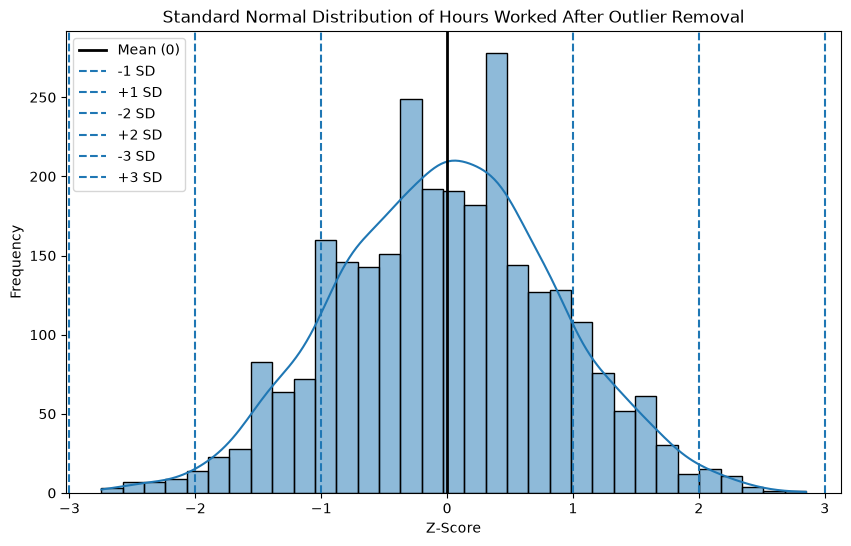

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_new,
    x="z_score_hours_working",
    kde=True
)

# Mean of standard normal distribution
plt.axvline(0, color="black", linestyle="-", linewidth=2, label="Mean (0)")

# Standard deviation boundaries
plt.axvline(-1, linestyle="--", label="-1 SD")
plt.axvline(1, linestyle="--", label="+1 SD")

plt.axvline(-2, linestyle="--", label="-2 SD")
plt.axvline(2, linestyle="--", label="+2 SD")

plt.axvline(-3, linestyle="--", label="-3 SD")
plt.axvline(3, linestyle="--", label="+3 SD")

plt.title("Standard Normal Distribution of Hours Worked After Outlier Removal")
plt.xlabel("Z-Score")
plt.ylabel("Frequency")
plt.legend()

plt.show()